# Fashion-MNIST classifier - MLP from scratch

Goal: classify 28×28 grayscale clothing images into 10 categories using a NumPy MLP with the Adam optimizer.

Pipeline:
1. Load Fashion-MNIST from HuggingFace
2. Preview a few images
3. Preprocess: flatten + normalize + one-hot
4. Build the MLP class (softmax output, Adam updates)
5. Mini-batch training loop
6. Evaluate on the test set + visualize predictions

## 1. Imports and class names

In [1]:
%pip install datasets

  Using cached datasets-4.8.5-py3-none-any.whl.metadata (19 kB)
  Using cached multiprocess-0.70.19-py312-none-any.whl.metadata (7.5 kB)
Using cached datasets-4.8.5-py3-none-any.whl (528 kB)
Using cached multiprocess-0.70.19-py312-none-any.whl (150 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'c:\\Python312\\Scripts\\datasets-cli.exe' -> 'c:\\Python312\\Scripts\\datasets-cli.exe.deleteme'


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

np.random.seed(42)

c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Fashion-MNIST

In [3]:
ds = load_dataset("fashion_mnist")

print("splits:", list(ds.keys()))
print("train size:", len(ds["train"]))
print("test size:", len(ds["test"]))
print("sample 0:", ds["train"][0])

splits: ['train', 'test']
train size: 60000
test size: 10000
sample 0: {'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28 at 0x2C47E3487A0>, 'label': 9}


## 3. Peek at a few images

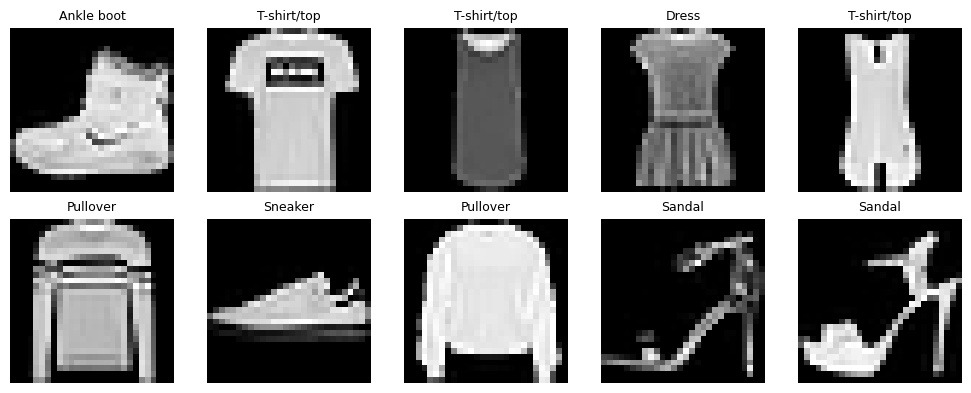

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    sample = ds["train"][i]
    ax.imshow(sample["image"], cmap="gray")
    ax.set_title(CLASS_NAMES[sample["label"]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Preprocess: flatten, normalize, one-hot

- Flatten 28×28 → 784
- Scale pixels from [0, 255] to [0, 1] (small inputs train faster and more stably)
- One-hot encode labels for softmax + cross-entropy

In [5]:
def preprocess(split):
    images = np.array([np.array(s["image"]) for s in split], dtype=np.float32)
    images = images.reshape(len(split), -1) / 255.0
    labels = np.array([s["label"] for s in split], dtype=np.int64)
    return images, labels


def one_hot(y, n_classes=10):
    out = np.zeros((y.shape[0], n_classes), dtype=np.float32)
    out[np.arange(y.shape[0]), y] = 1
    return out


X_train, y_train = preprocess(ds["train"])
X_test,  y_test  = preprocess(ds["test"])

Y_train = one_hot(y_train)
Y_test  = one_hot(y_test)

print("X_train:", X_train.shape, X_train.dtype)
print("Y_train:", Y_train.shape)
print("X_test :", X_test.shape)
print("Y_test :", Y_test.shape)
print("pixel range:", X_train.min(), "->", X_train.max())
print("label[0]:", y_train[0], "=", CLASS_NAMES[y_train[0]])
print("one-hot[0]:", Y_train[0])

X_train: (60000, 784) float32
Y_train: (60000, 10)
X_test : (10000, 784)
Y_test : (10000, 10)
pixel range: 0.0 -> 1.0
label[0]: 9 = Ankle boot
one-hot[0]: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [7]:
# activations 
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

def softmax(z):
    # subtract max for numerical stability (prevents overflow in exp)
    z_shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


In [8]:
class MLP:
    def __init__(self, n_input, n_hidden, n_output, lr=0.01,
                 beta1=0.9, beta2=0.999, eps=1e-8):
        # random small weights, zero biases
        self.W1 = np.random.randn(n_input,  n_hidden) * 0.5
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.randn(n_hidden, n_output) * 0.5
        self.b2 = np.zeros((1, n_output))
        self.lr = lr

        # adam hyperparameters
        self.beta1 = beta1   # decay rate for direction memory (m)
        self.beta2 = beta2   # decay rate for magnitude memory (v)
        self.eps   = eps     # tiny number to prevent /0
        self.t     = 0       # timestep counter (for bias correction)

        # FIRST moment: running avg of gradient (direction, like momentum)
        self.mW1 = np.zeros_like(self.W1)
        self.mb1 = np.zeros_like(self.b1)
        self.mW2 = np.zeros_like(self.W2)
        self.mb2 = np.zeros_like(self.b2)

        # SECOND moment: running avg of gradient squared (magnitude, for per-weight LR)
        self.vW1 = np.zeros_like(self.W1)
        self.vb1 = np.zeros_like(self.b1)
        self.vW2 = np.zeros_like(self.W2)
        self.vb2 = np.zeros_like(self.b2)

    # forward propagation 
    def forward(self, X):
        # layer 1: input -> hidden
        self.Z1 = X @ self.W1 + self.b1          # weighted sum
        self.A1 = sigmoid(self.Z1)                # activation

        # layer 2: hidden -> output
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)          # final prediction
        return self.A2

    # backpropagation 
    def backward(self, X, y):
        m = X.shape[0]  # number of samples

        # OUTPUT LAYER: how wrong was the prediction? 
        dZ2 = self.A2 - y                          # error at output
        dW2 = (self.A1.T @ dZ2) / m                # gradient for W2
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # HIDDEN LAYER: propagate blame backward 
        dA1 = dZ2 @ self.W2.T                      # blame on hidden activations
        dZ2_hidden = dA1 * sigmoid_derivative(self.A1)   # apply activation derivative
        dW1 = (X.T @ dZ2_hidden) / m
        db1 = np.sum(dZ2_hidden, axis=0, keepdims=True) / m

        # ADAM UPDATE
        self.t += 1
        b1, b2, eps, lr = self.beta1, self.beta2, self.eps, self.lr

        # 1) update first moment (direction)
        self.mW2 = b1 * self.mW2 + (1 - b1) * dW2
        self.mb2 = b1 * self.mb2 + (1 - b1) * db2
        self.mW1 = b1 * self.mW1 + (1 - b1) * dW1
        self.mb1 = b1 * self.mb1 + (1 - b1) * db1

        # 2) update second moment (magnitude — gradient squared)
        self.vW2 = b2 * self.vW2 + (1 - b2) * (dW2 ** 2)
        self.vb2 = b2 * self.vb2 + (1 - b2) * (db2 ** 2)
        self.vW1 = b2 * self.vW1 + (1 - b2) * (dW1 ** 2)
        self.vb1 = b2 * self.vb1 + (1 - b2) * (db1 ** 2)

        # 3) bias correction — early steps under-estimate moments since they start at 0
        bc1 = 1 - b1 ** self.t
        bc2 = 1 - b2 ** self.t

        # 4) step: lr * (corrected m) / (sqrt(corrected v) + eps)
        self.W2 -= lr * (self.mW2 / bc1) / (np.sqrt(self.vW2 / bc2) + eps)
        self.b2 -= lr * (self.mb2 / bc1) / (np.sqrt(self.vb2 / bc2) + eps)
        self.W1 -= lr * (self.mW1 / bc1) / (np.sqrt(self.vW1 / bc2) + eps)
        self.b1 -= lr * (self.mb1 / bc1) / (np.sqrt(self.vb1 / bc2) + eps)

        
    #  training loop 
    def train(self, X, y, X_test, y_test, epochs=20, batch_size=128):
      n = X.shape[0]
      for epoch in range(epochs):
          # shuffle indices each epoch
          idx = np.random.permutation(n)
          X_shuf, y_shuf = X[idx], y[idx]

          # iterate in mini-batches
          for start in range(0, n, batch_size):
              end = start + batch_size
              X_batch = X_shuf[start:end]
              y_batch = y_shuf[start:end]
              self.forward(X_batch)
              self.backward(X_batch, y_batch)

          # end of epoch — full-set loss + train/test accuracy
          train_pred = self.forward(X)
          train_loss = -np.mean(np.sum(y * np.log(train_pred + 1e-8), axis=1))
          train_acc  = np.mean(np.argmax(train_pred, axis=1) == np.argmax(y, axis=1))

          test_pred = self.forward(X_test)
          test_acc  = np.mean(np.argmax(test_pred, axis=1) == np.argmax(y_test, axis=1))

          print(f"Epoch {epoch+1:2d} | Loss: {train_loss:.4f} | "
                f"Train acc: {train_acc:.2%} | Test acc: {test_acc:.2%}")

In [9]:
model = MLP(n_input=784, n_hidden=128, n_output=10, lr=0.001)
model.train(X_train, Y_train, X_test, Y_test, epochs=20, batch_size=128)

Epoch  1 | Loss: 0.5012 | Train acc: 82.14% | Test acc: 80.92%
Epoch  2 | Loss: 0.4293 | Train acc: 84.81% | Test acc: 83.43%
Epoch  3 | Loss: 0.3897 | Train acc: 86.05% | Test acc: 84.00%
Epoch  4 | Loss: 0.3670 | Train acc: 86.78% | Test acc: 85.03%
Epoch  5 | Loss: 0.3443 | Train acc: 87.66% | Test acc: 85.33%
Epoch  6 | Loss: 0.3297 | Train acc: 88.25% | Test acc: 85.87%
Epoch  7 | Loss: 0.3148 | Train acc: 88.69% | Test acc: 85.80%
Epoch  8 | Loss: 0.2981 | Train acc: 89.26% | Test acc: 86.32%
Epoch  9 | Loss: 0.2889 | Train acc: 89.57% | Test acc: 86.54%
Epoch 10 | Loss: 0.2822 | Train acc: 89.75% | Test acc: 86.46%
Epoch 11 | Loss: 0.2723 | Train acc: 90.23% | Test acc: 86.94%
Epoch 12 | Loss: 0.2643 | Train acc: 90.47% | Test acc: 86.86%
Epoch 13 | Loss: 0.2529 | Train acc: 90.88% | Test acc: 86.96%
Epoch 14 | Loss: 0.2613 | Train acc: 90.43% | Test acc: 86.58%
Epoch 15 | Loss: 0.2432 | Train acc: 91.18% | Test acc: 87.25%
Epoch 16 | Loss: 0.2333 | Train acc: 91.72% | Test acc: